# AttnRes Research Pipeline Results

This notebook visualizes the completed outputs for:
- Part 1: temporal evolution of large-model alpha heatmaps
- Part 2: scale comparison of alpha heatmaps
- Part 3: VLM training, evaluation, checkpoints, and alpha-routing diagnostics


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display


def find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'experiments' / 'attnres_research_pipeline.py').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not find AttnResGPT-next-scale repo root')


def load_env(path: Path) -> None:
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        if '=' not in line or line.strip().startswith('#'):
            continue
        key, value = line.split('=', 1)
        os.environ.setdefault(key.strip(), value.strip())


REPO_DIR = find_repo_root()
load_env(REPO_DIR / '.env')
OUTPUTS_DIR = REPO_DIR / 'outputs'
RESEARCH_DIR = OUTPUTS_DIR / 'research_pipeline'
VLM_OUTPUT_DIR = OUTPUTS_DIR / 'vlm_attnres_flickr30k'
VLM_CHECKPOINT_DIR = REPO_DIR / 'checkpoints' / 'vlm_attnres_flickr30k'

print('REPO_DIR =', REPO_DIR)
print('WANDB_API_KEY set =', bool(os.environ.get('WANDB_API_KEY')))


ModuleNotFoundError: No module named 'seaborn'

In [2]:
PART1_HEATMAP = RESEARCH_DIR / 'part1_temporal_alpha_heatmaps.png'
PART1_ENTROPY = RESEARCH_DIR / 'part1_temporal_entropy.png'
PART2_HEATMAP = RESEARCH_DIR / 'part2_scale_alpha_heatmaps.png'
PART2_EMBEDDING = RESEARCH_DIR / 'part2_scale_embedding_contribution.png'

for path in [PART1_HEATMAP, PART1_ENTROPY, PART2_HEATMAP, PART2_EMBEDDING]:
    print(path.name, path.exists())


part1_temporal_alpha_heatmaps.png True
part1_temporal_entropy.png True
part2_scale_alpha_heatmaps.png True
part2_scale_embedding_contribution.png True


'part1_temporal_alpha_heatmaps.png'

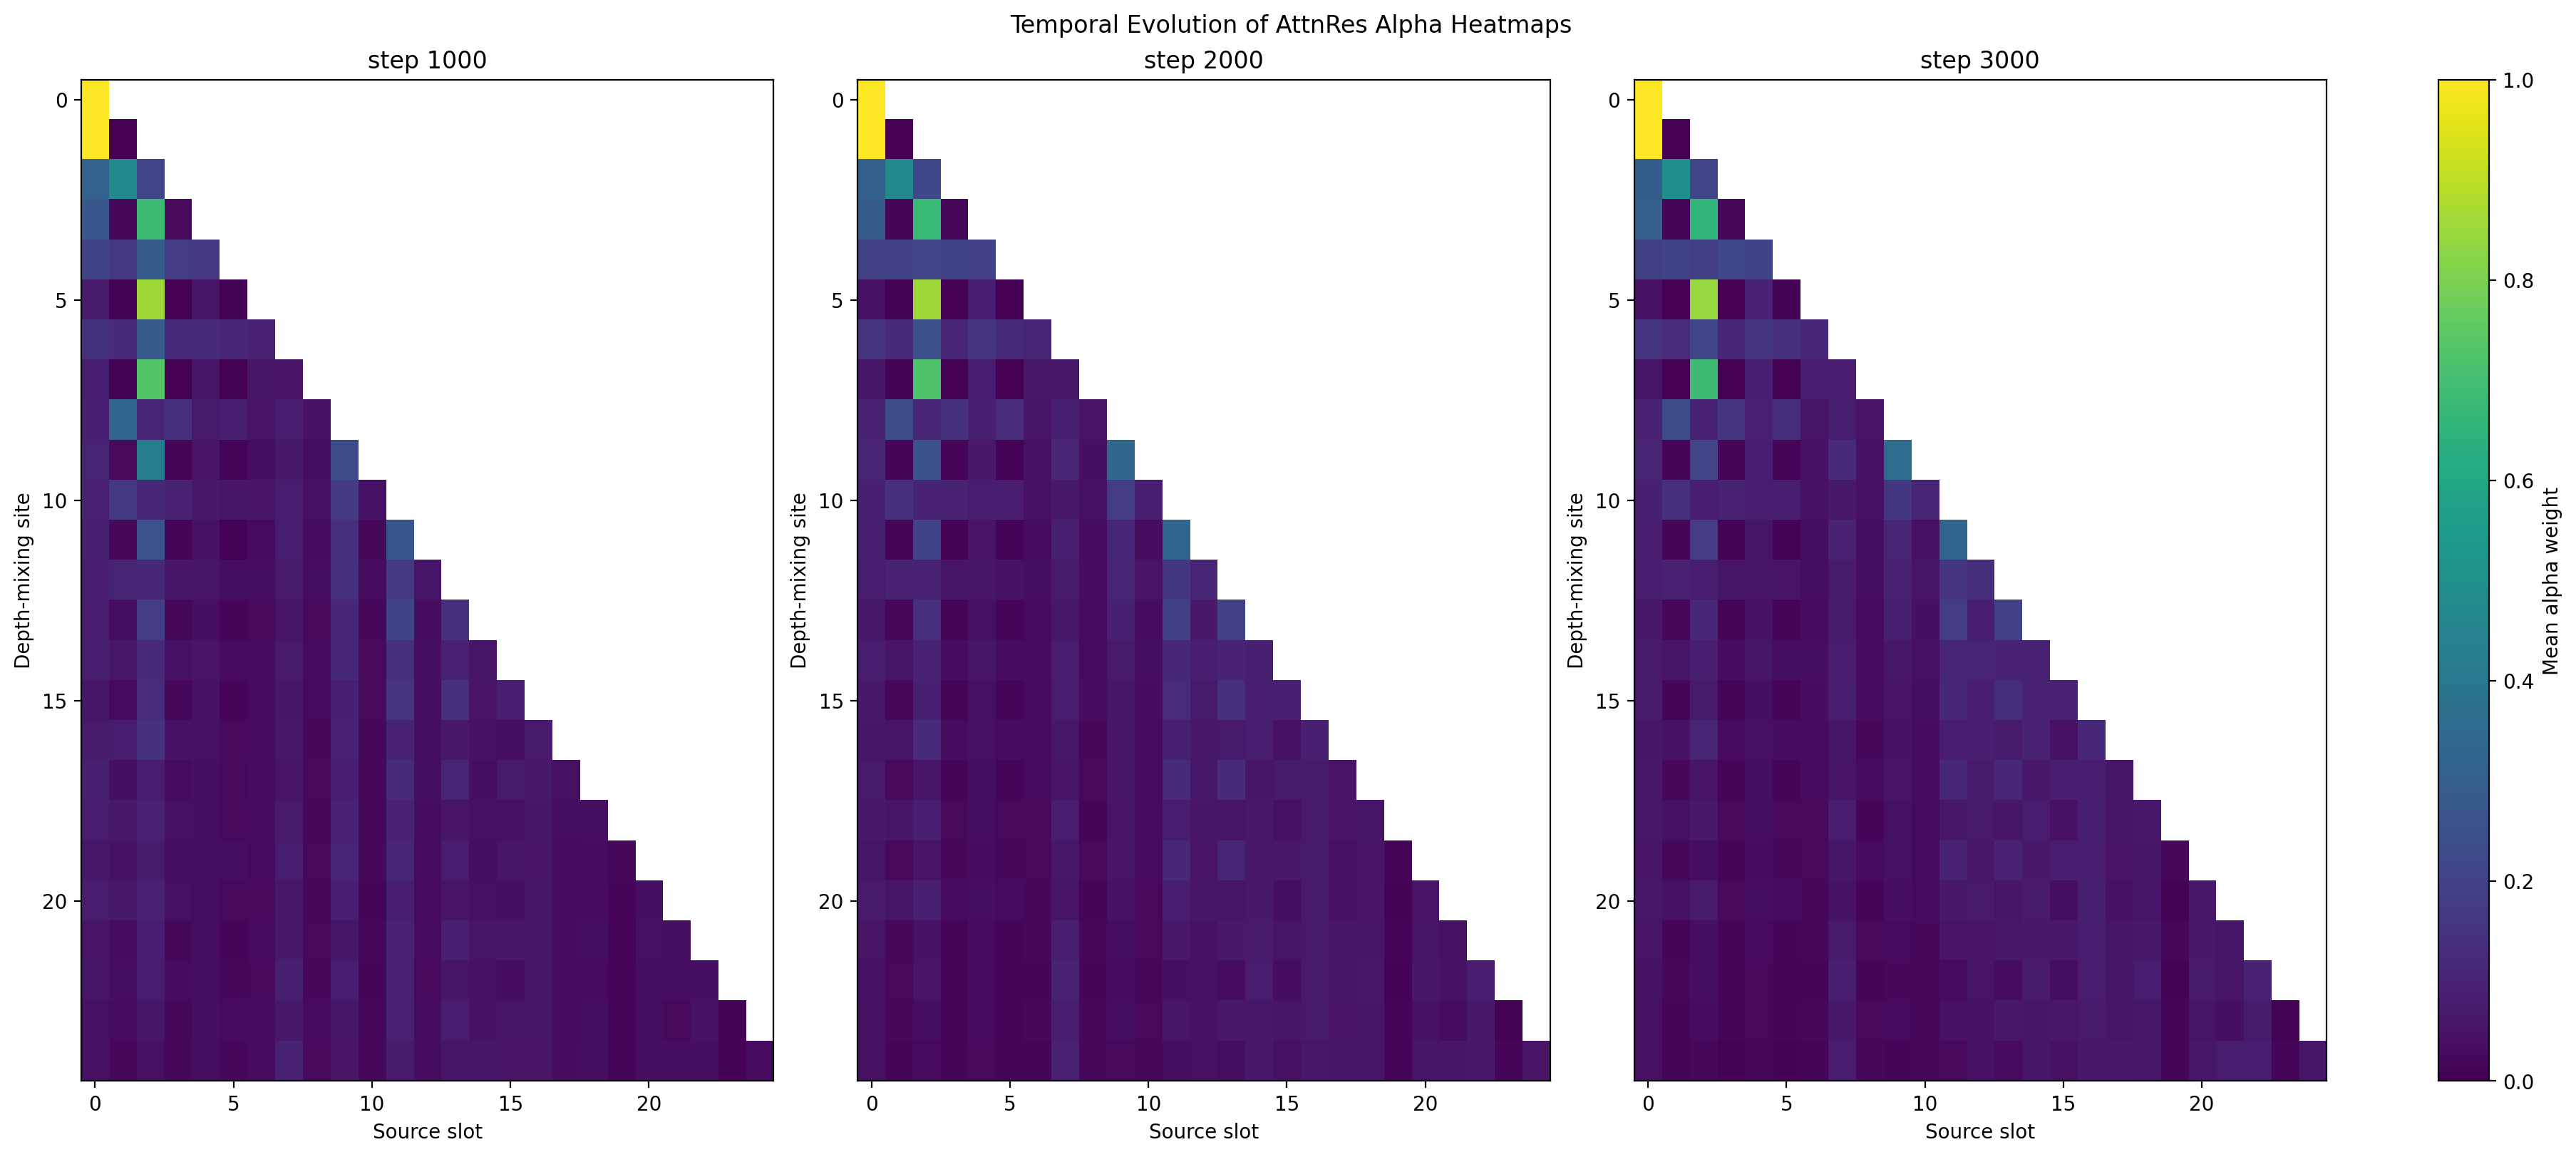

'part1_temporal_entropy.png'

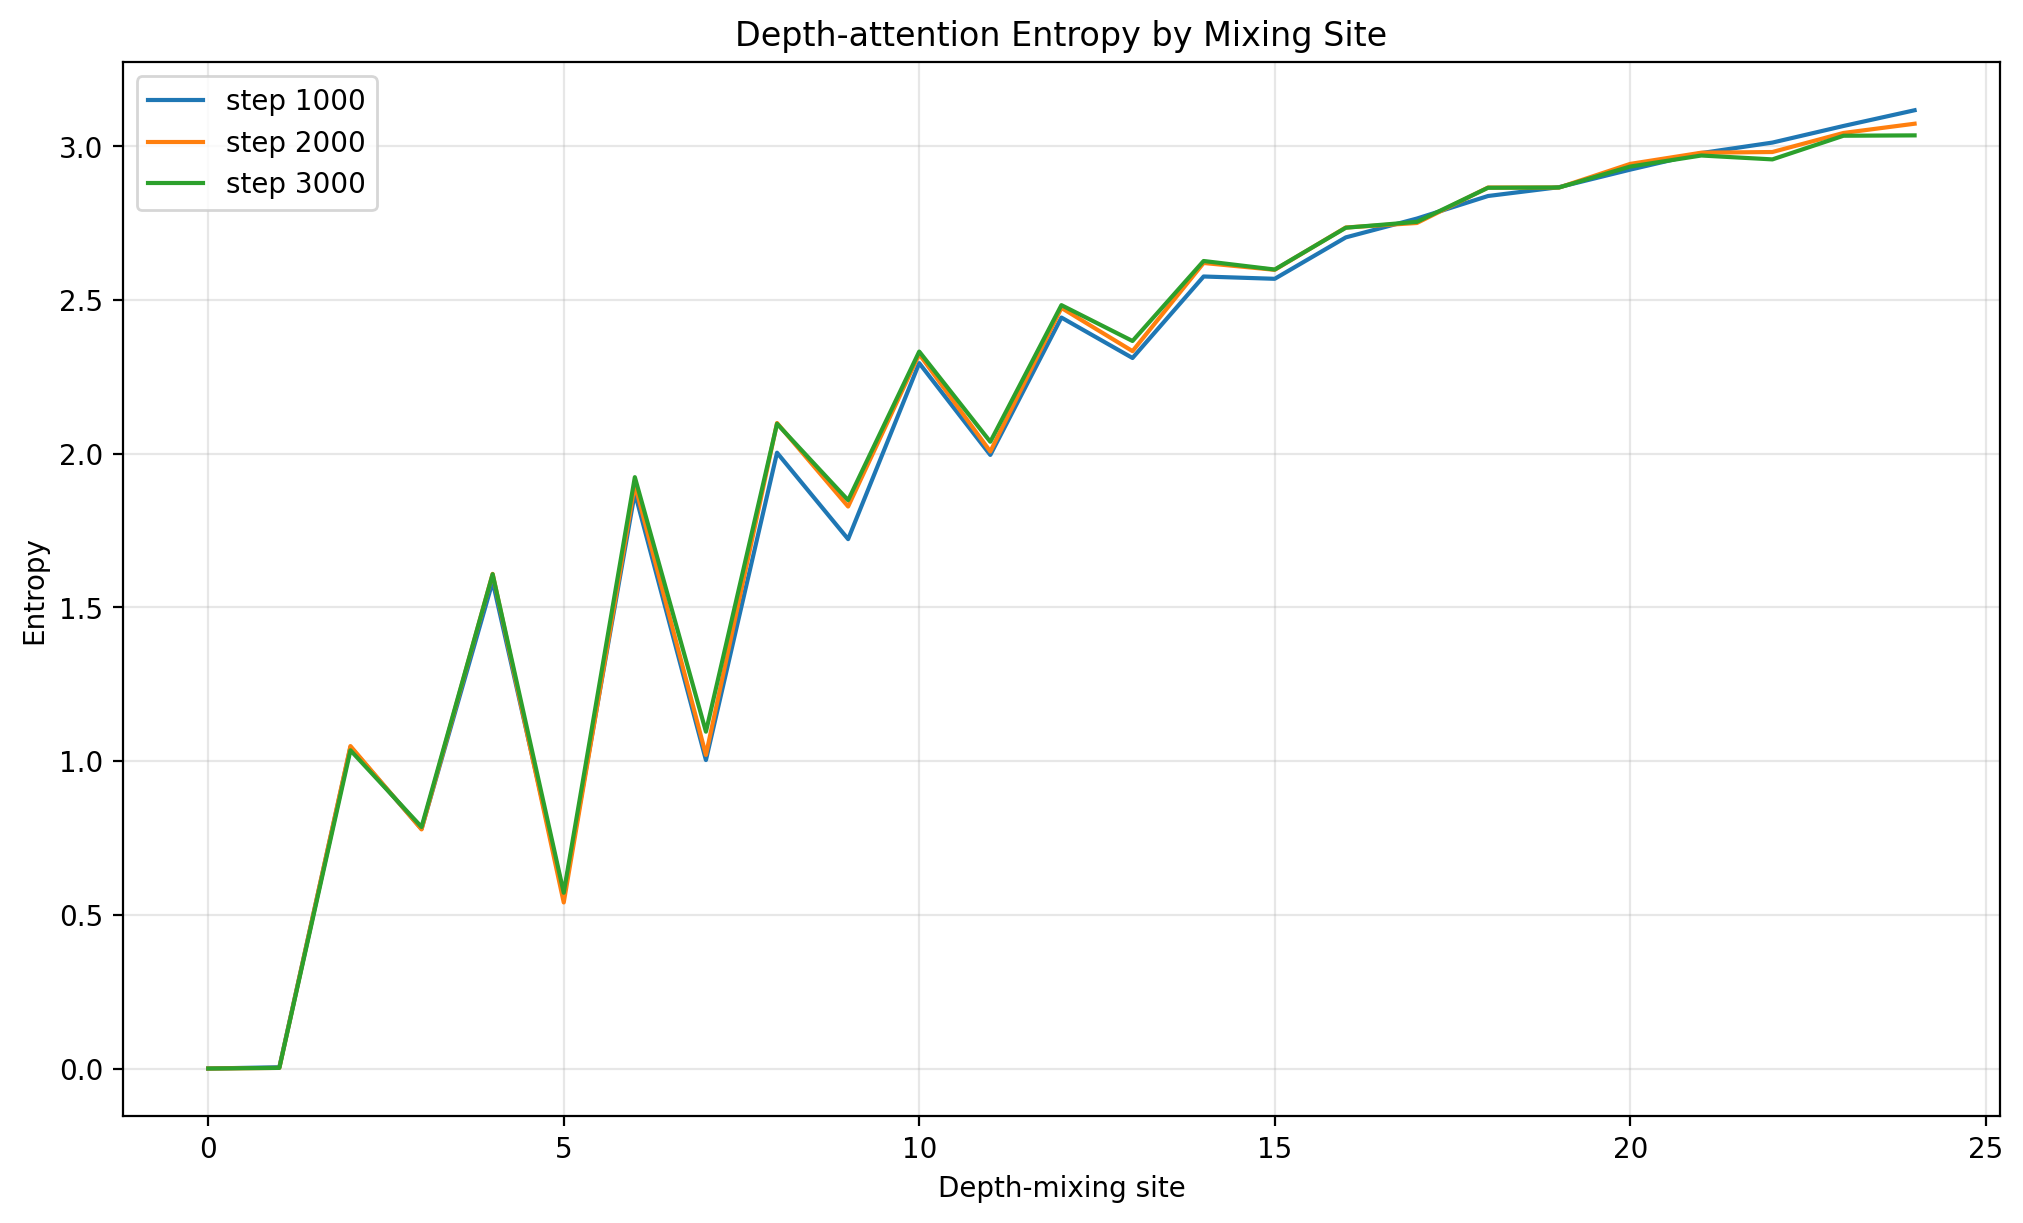

'part2_scale_alpha_heatmaps.png'

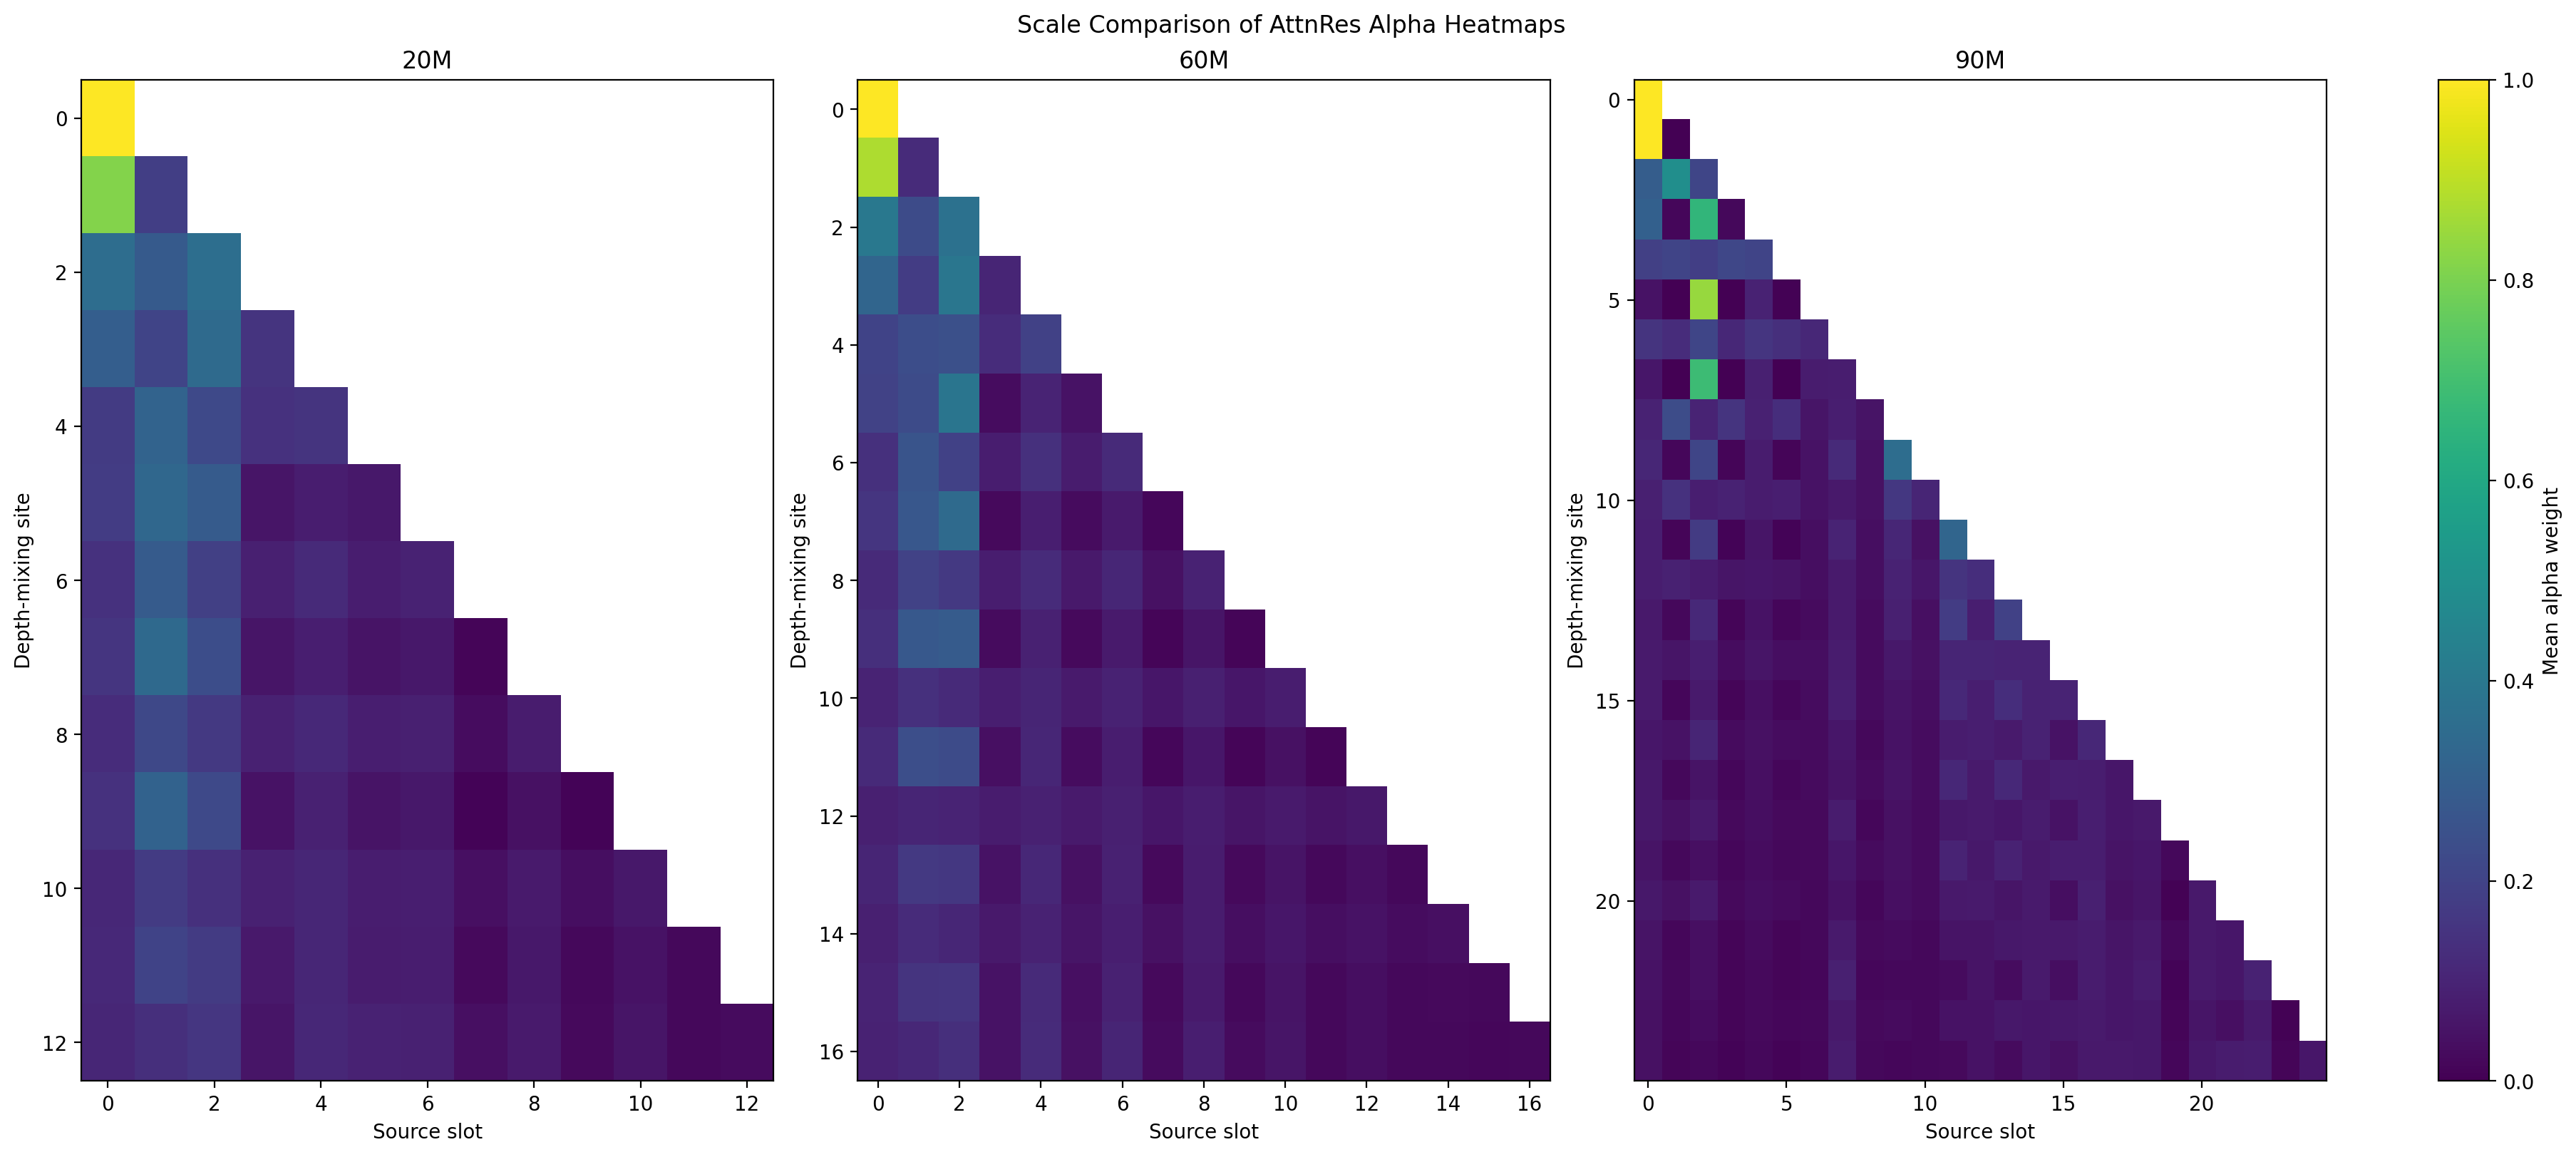

'part2_scale_embedding_contribution.png'

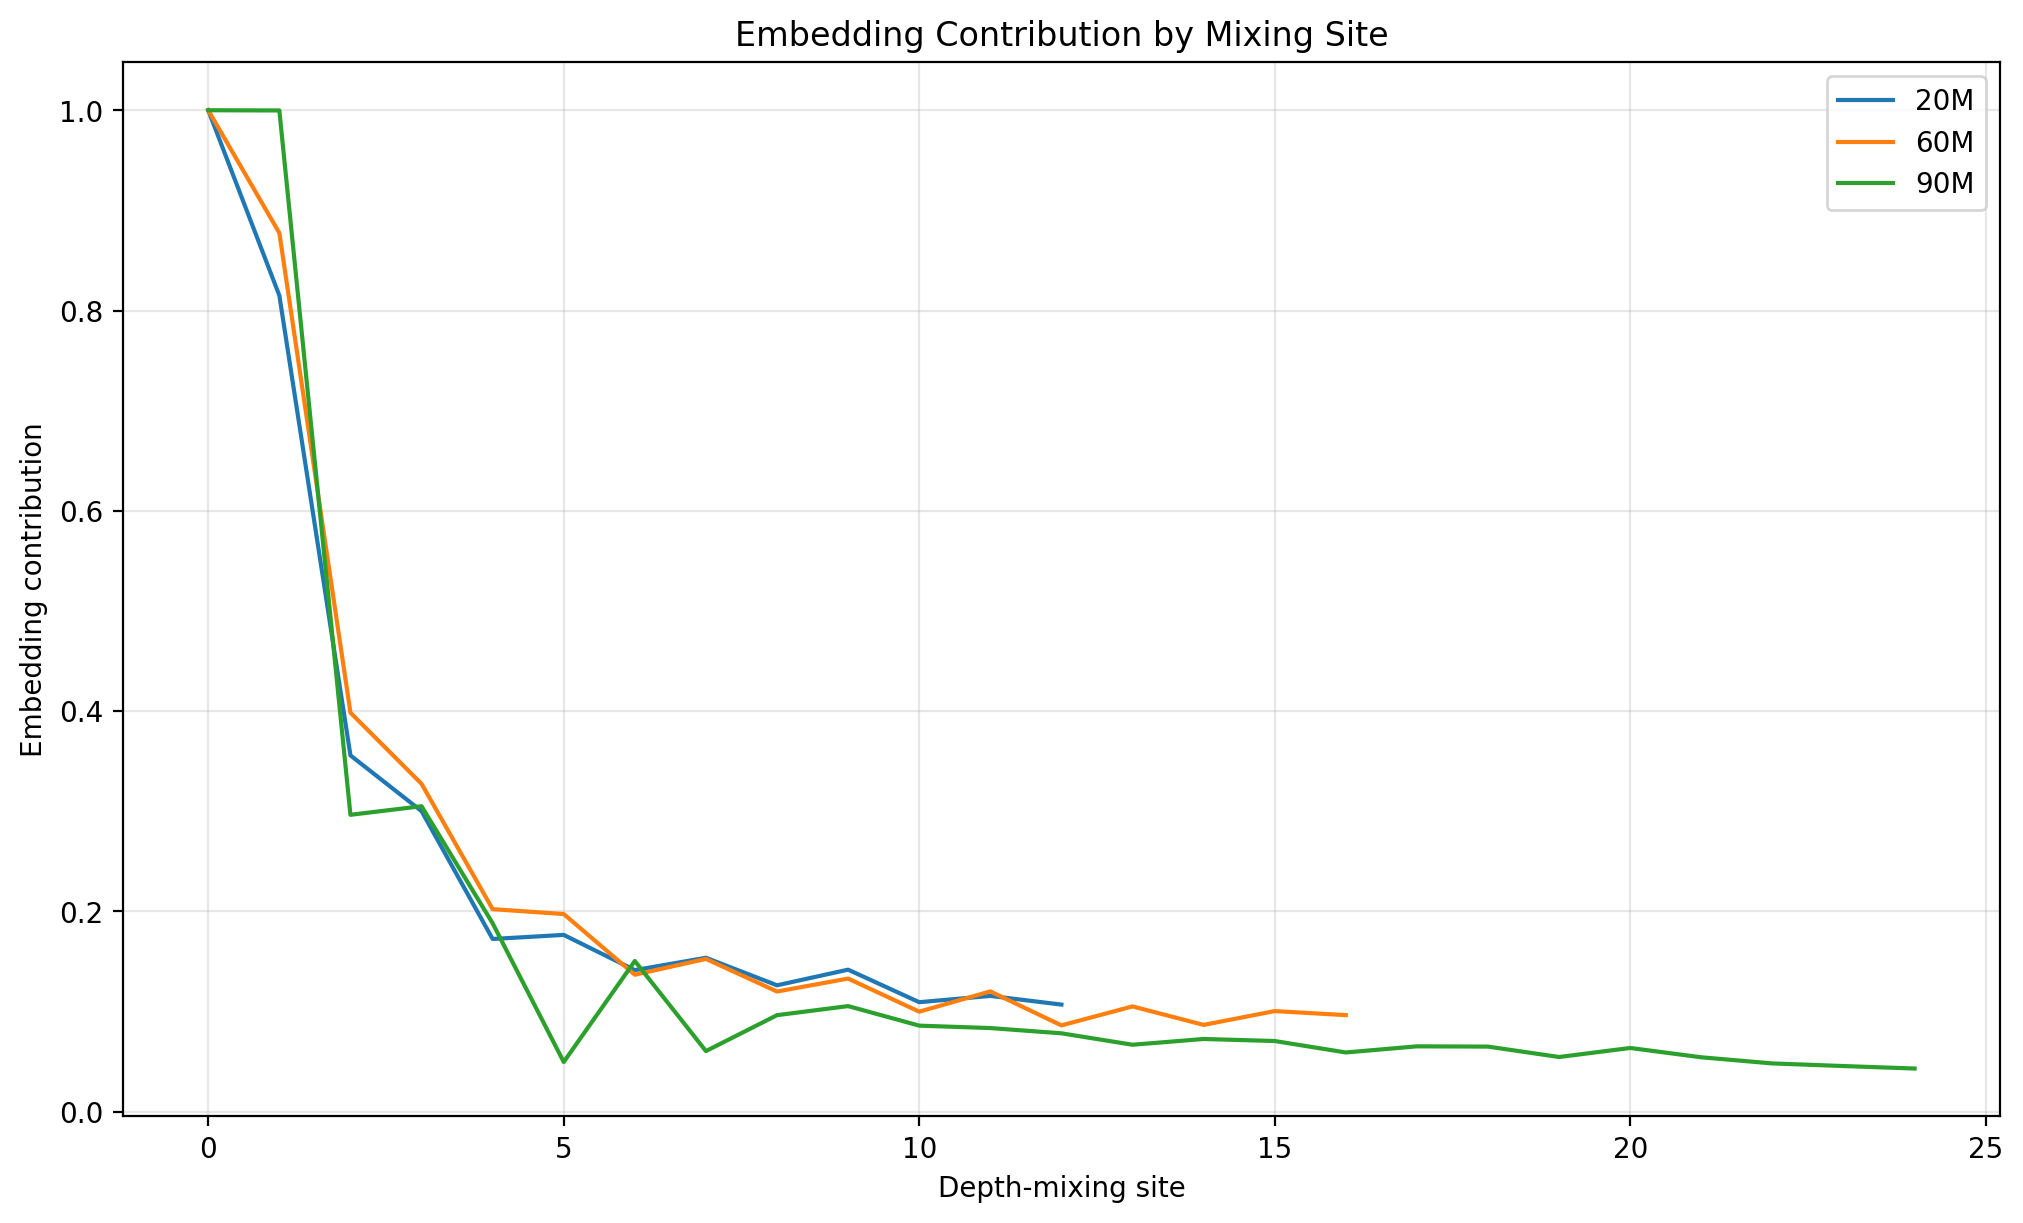

In [3]:
for path in [PART1_HEATMAP, PART1_ENTROPY, PART2_HEATMAP, PART2_EMBEDDING]:
    if path.exists():
        display(path.name)
        display(Image(filename=str(path)))


In [2]:
import wandb

wandb.login(key=os.environ['WANDB_API_KEY'], relogin=True)
api = wandb.Api()

ENTITY = 'atin5551-uc-davis'
PROJECT = 'attnres-next-scale'
LARGE_RUN = f'{ENTITY}/{PROJECT}/tinystories_large_attnres_ctx512_steps3000_seed42'
SCALE_RUN = f'{ENTITY}/{PROJECT}/attnres_scale_comparison'
VLM_RUN = f'{ENTITY}/{PROJECT}/vlm_attnres_flickr30k'


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/atin5551/.netrc
wandb: Currently logged in as: atin5551 (atin5551-uc-davis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [16]:
def history_df(run_path: str) -> pd.DataFrame:
    run = api.run(run_path)
    return pd.DataFrame(list(run.scan_history()))


def last_nonnull_per_step(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    keep = ['_step'] + [col for col in cols if col in df.columns]
    work = df[keep].copy()
    value_cols = [col for col in keep if col != '_step']
    if not value_cols:
        return work.iloc[0:0]
    work = work.dropna(subset=value_cols, how='all')
    return work.groupby('_step', as_index=False).last().sort_values('_step')


In [4]:
large_run = api.run(LARGE_RUN)
scale_run = api.run(SCALE_RUN)
vlm_run = api.run(VLM_RUN)

print('large state:', large_run.state)
print('scale state:', scale_run.state)
print('vlm state:', vlm_run.state)

for run, name in [(large_run, 'large'), (scale_run, 'scale'), (vlm_run, 'vlm')]:
    print('\n', name.upper(), 'summary sample')
    for key in list(dict(run.summary).keys())[:20]:
        print(' ', key, '=', run.summary[key])


large state: finished
scale state: finished
vlm state: running

 LARGE summary sample
  _runtime = 11825
  _step = 3002
  _timestamp = 1774262263.1724448
  _wandb = {'runtime': 11825}
  activation_norms/blocks.0.attn = 15.821495056152344
  activation_norms/blocks.0.mlp = 27.682418823242188
  activation_norms/blocks.1.attn = 22.064796447753903
  activation_norms/blocks.1.mlp = 18.12045669555664
  activation_norms/blocks.10.attn = 8.841583251953125
  activation_norms/blocks.10.mlp = 13.984874725341797
  activation_norms/blocks.11.attn = 27.82286071777344
  activation_norms/blocks.11.mlp = 21.996320724487305
  activation_norms/blocks.2.attn = 17.769794464111328
  activation_norms/blocks.2.mlp = 20.144241333007812
  activation_norms/blocks.3.attn = 9.993175506591797
  activation_norms/blocks.3.mlp = 19.829442977905273
  activation_norms/blocks.4.attn = 17.334705352783203
  activation_norms/blocks.4.mlp = 13.549437522888184
  activation_norms/blocks.5.attn = 14.565353393554688
  activation_

In [17]:
vlm_hist = history_df(VLM_RUN)
print(vlm_hist.shape)
vlm_hist.tail()


(111, 8)


,train/loss,train/grad_norm,epoch,train/learning_rate,_timestamp,_step,train/perplexity,_runtime
106,5.308533,1.626857,1,0.0001,1.774285e+09,107,202.053543,20596.491037
107,5.109602,1.930934,1,0.0001,1.774285e+09,108,165.604431,20902.874090
108,5.370720,1.537621,1,0.0001,1.774286e+09,109,215.017609,21118.793947
109,5.467866,1.670798,1,0.0001,1.774286e+09,110,236.953979,21377.223508
110,5.491762,1.715296,1,0.0001,1.774286e+09,111,242.684479,21829.362054


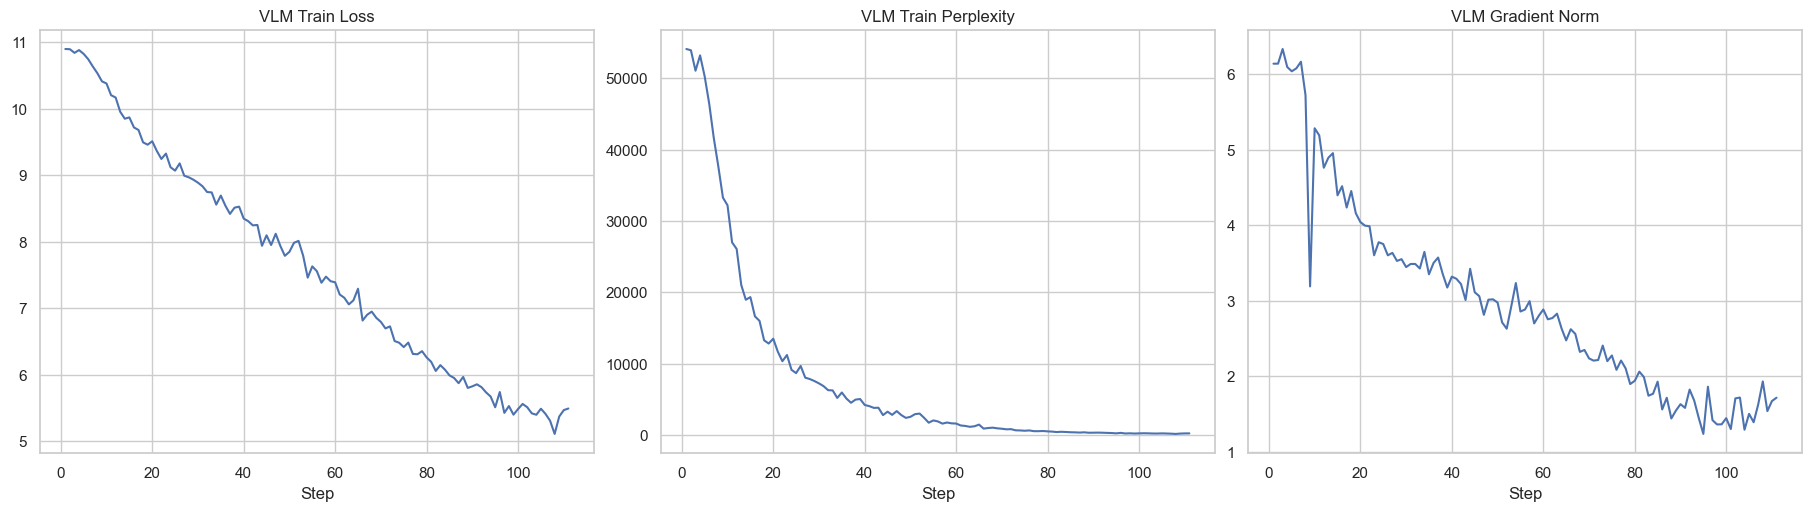

In [8]:
sns.set_theme(style='whitegrid')

train_cols = ['train/loss', 'train/perplexity', 'train/grad_norm']
eval_cols = ['eval/loss', 'eval/perplexity']
train_df = last_nonnull_per_step(vlm_hist, train_cols)
eval_df = last_nonnull_per_step(vlm_hist, eval_cols)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
if not train_df.empty:
    axes[0].plot(train_df['_step'], train_df['train/loss'])
    axes[0].set_title('VLM Train Loss')
    axes[1].plot(train_df['_step'], train_df['train/perplexity'])
    axes[1].set_title('VLM Train Perplexity')
    axes[2].plot(train_df['_step'], train_df['train/grad_norm'])
    axes[2].set_title('VLM Gradient Norm')
for ax in axes:
    ax.set_xlabel('Step')
plt.show()

if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].plot(eval_df['_step'], eval_df['eval/loss'])
    axes[0].set_title('VLM Eval Loss')
    axes[1].plot(eval_df['_step'], eval_df['eval/perplexity'])
    axes[1].set_title('VLM Eval Perplexity')
    for ax in axes:
        ax.set_xlabel('Step')
    plt.show()


In [9]:
alpha_mean_cols = [
    'alpha/vision_entropy_mean',
    'alpha/language_entropy_mean',
    'alpha/vision_embedding_mean',
    'alpha/language_embedding_mean',
]
alpha_means = last_nonnull_per_step(vlm_hist, alpha_mean_cols)
alpha_means.tail()


,_step


In [10]:
if not alpha_means.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    axes[0].plot(alpha_means['_step'], alpha_means['alpha/vision_entropy_mean'], label='vision')
    axes[0].plot(alpha_means['_step'], alpha_means['alpha/language_entropy_mean'], label='language')
    axes[0].set_title('Mean Alpha Entropy')
    axes[0].legend()
    axes[1].plot(alpha_means['_step'], alpha_means['alpha/vision_embedding_mean'], label='vision')
    axes[1].plot(alpha_means['_step'], alpha_means['alpha/language_embedding_mean'], label='language')
    axes[1].set_title('Mean Embedding Contribution')
    axes[1].legend()
    for ax in axes:
        ax.set_xlabel('Step')
    plt.show()


In [11]:
vision_entropy_cols = sorted([col for col in vlm_hist.columns if col.startswith('alpha/vision_entropy/site_')])
language_entropy_cols = sorted([col for col in vlm_hist.columns if col.startswith('alpha/language_entropy/site_')])
vision_embedding_cols = sorted([col for col in vlm_hist.columns if col.startswith('alpha/vision_embedding/site_')])
language_embedding_cols = sorted([col for col in vlm_hist.columns if col.startswith('alpha/language_embedding/site_')])

per_site = last_nonnull_per_step(vlm_hist, vision_entropy_cols + language_entropy_cols + vision_embedding_cols + language_embedding_cols)
per_site.tail(3)


,_step


In [12]:
if not per_site.empty:
    latest = per_site.iloc[-1]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    axes[0].plot(range(len(vision_entropy_cols)), [latest[col] for col in vision_entropy_cols], label='vision')
    axes[0].plot(range(len(language_entropy_cols)), [latest[col] for col in language_entropy_cols], label='language')
    axes[0].set_title('Latest Per-Site Alpha Entropy')
    axes[0].set_xlabel('Depth-mixing site')
    axes[0].legend()
    axes[1].plot(range(len(vision_embedding_cols)), [latest[col] for col in vision_embedding_cols], label='vision')
    axes[1].plot(range(len(language_embedding_cols)), [latest[col] for col in language_embedding_cols], label='language')
    axes[1].set_title('Latest Per-Site Embedding Contribution')
    axes[1].set_xlabel('Depth-mixing site')
    axes[1].legend()
    plt.show()


In [13]:
print('Local VLM figure files:')
for path in sorted(VLM_OUTPUT_DIR.glob('*.png')):
    print(' ', path.name)

print('\nLocal VLM checkpoints:')
for path in sorted(VLM_CHECKPOINT_DIR.glob('step_*.pt')):
    print(' ', path.name)


Local VLM figure files:


NameError: name 'VLM_OUTPUT_DIR' is not defined

In [14]:
for path in sorted(VLM_OUTPUT_DIR.glob('*.png'))[-6:]:
    display(path.name)
    display(Image(filename=str(path)))


NameError: name 'VLM_OUTPUT_DIR' is not defined

In [15]:
print('Logged VLM artifacts:')
for artifact in vlm_run.logged_artifacts():
    print(artifact.name, '| type=', artifact.type)


Logged VLM artifacts:
